In [24]:
import pickle, glob, blosc, csv

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

from itertools import product, chain
from shapely.geometry import Point

plt.rcParams['legend.handlelength'] = 1
plt.rcParams['legend.handleheight'] = 1.125
plt.rcParams["font.family"]         = "Avenir"
#mpl.rcParams['pdf.fonttype'] = 42

path_to_data    = r'/Users/Guille/Desktop/caiso_power/data/'
path_to_pds    = r"/Users/Guille/Desktop/caiso_power/data/dataset-2023/"
path_to_aux    = r"/Users/Guille/Desktop/caiso_power/data/auxiliary/"
path_to_images = r"/Users/Guille/Desktop/caiso_power/images/"

colors_1_ = ['#7d6674', '#006995', '#f48d64', '#09155a', '#e6cd94', '#0041a5']
colors_2_ = ['#126463', '#2CB7B5', '#CA8250']
colors_3_ = ['#1F390D', '#756A00', '#D8A581', '#92918B']

In [25]:
def _load_date(path, columns_ = ['NP15', 'ZP26', 'ZP26']):
    dfs_ = []
    for file in glob.glob(path):
        #print(file)

        X_ = pickle.load(open(file,'rb'))

        file     = file.split('/')[-1][:-4]
        resource = file.split('_')[0]
        data     = file.split('_')[1]

        x_             = X_[columns_].copy()
        x_['year']     = int(data[:4])
        x_['month']    = int(data[-4:-2])
        x_['day']      = int(data[-2:])
        x_['interval'] = x_.index
        x_['date']     = data

        dfs_.append(x_)
        
    return pd.concat(dfs_, axis = 0).reset_index(drop = True)
        
solar_fc_ = _load_date(columns_ = ['NP15', 'SP15', 'ZP26'],
                       path     = "/Users/Guille/Desktop/forecasts/Solar*.pkl")   
solar_ac_ = _load_date(columns_ = ['NP15', 'SP15', 'ZP26'],
                       path     = "/Users/Guille/Desktop/actuals/Solar*.pkl")  

wind_fc_ = _load_date(columns_ = ['NP15', 'SP15'],
                      path     = "/Users/Guille/Desktop/forecasts/Wind*.pkl")   
wind_ac_ = _load_date(columns_ = ['NP15', 'SP15'],
                      path     = "/Users/Guille/Desktop/actuals/Wind*.pkl")   

load_fc_ = _load_date(columns_ = ['PGE-TAC', 'SCE-TAC', 'SDGE-TAC'],
                      path     = "/Users/Guille/Desktop/forecasts/Demand*.pkl")   
load_ac_ = _load_date(columns_ = ['PGE-TAC', 'SCE-TAC', 'SDGE-TAC'],
                      path     = "/Users/Guille/Desktop/actuals/Demand*.pkl") 

solar_ac_['type'] = 'actual'
solar_fc_['type'] = 'forecast'

wind_ac_['type'] = 'actual'
wind_fc_['type'] = 'forecast'

load_ac_['type'] = 'actual'
load_fc_['type'] = 'forecast'

solar_ = pd.concat([solar_ac_, solar_fc_], axis = 0).reset_index(drop = True)
wind_  = pd.concat([wind_ac_, wind_fc_], axis = 0).reset_index(drop = True)
load_  = pd.concat([load_ac_, load_fc_], axis = 0).reset_index(drop = True)
print(solar_.shape, wind_.shape, load_.shape)

solar_['total'] = solar_['NP15'] + solar_['SP15'] + solar_['ZP26']
wind_['total']  = wind_['NP15'] + wind_['SP15']
load_['total']  = load_['PGE-TAC'] + load_['SCE-TAC'] + load_['SDGE-TAC']

(63244, 9) (63316, 8) (63163, 9)


# Variability 
Net load with its spread, maybe seasonal average lines at CAISO level OR Demand, solar, and wind at CAISO level with seasonal average lines OR zone/ utility level data. 


In [26]:
solar_ppp_ = solar_.drop(columns = ['NP15', 'SP15', 'ZP26']).copy()
wind_ppp_  = wind_.drop(columns = ['NP15', 'SP15']).copy()
load_ppp_  = load_.drop(columns = ['PGE-TAC', 'SCE-TAC', 'SDGE-TAC']).copy()

solar_ppp_ = solar_ppp_.loc[solar_ppp_['type'] == 'actual'].reset_index(drop = True)
wind_ppp_  = wind_ppp_.loc[wind_ppp_['type'] == 'actual'].reset_index(drop = True)
load_ppp_  = load_ppp_.loc[load_ppp_['type'] == 'actual'].reset_index(drop = True)
    
solar_ppp_['resource'] = 'solar'
wind_ppp_['resource']  = 'wind'
load_ppp_['resource']  = 'demand'

all_ = pd.concat([solar_ppp_, wind_ppp_, load_ppp_], axis = 0).reset_index(drop = True).copy()

/Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3440: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/Guille/opt/anaconda3/envs/py38/lib/python3.8/site-packages/numpy/core/_methods.py:181: RuntimeWarning: invalid value encountered in true_divide
  ret = um.true_divide(


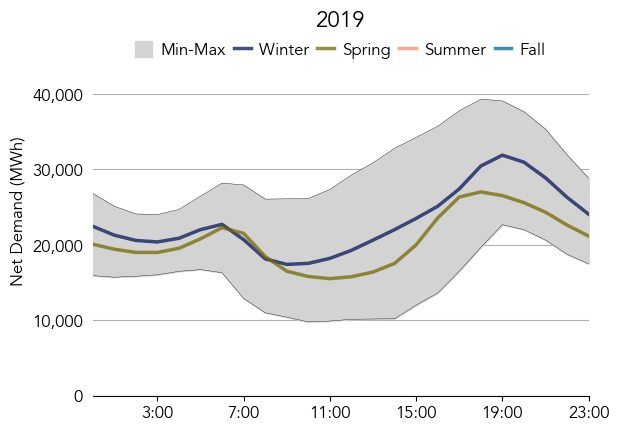

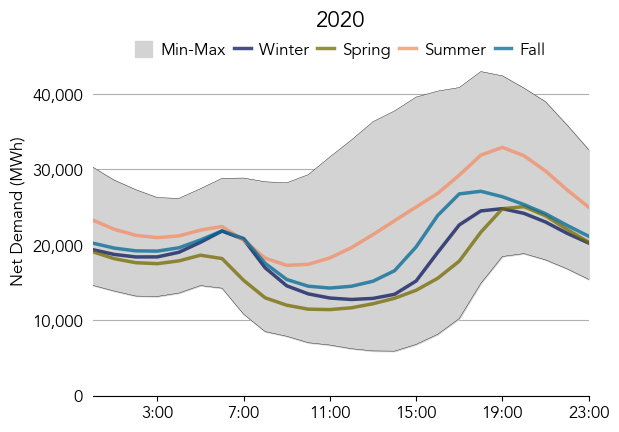

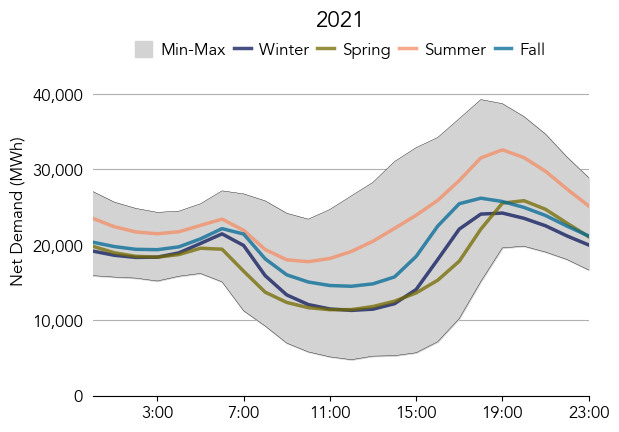

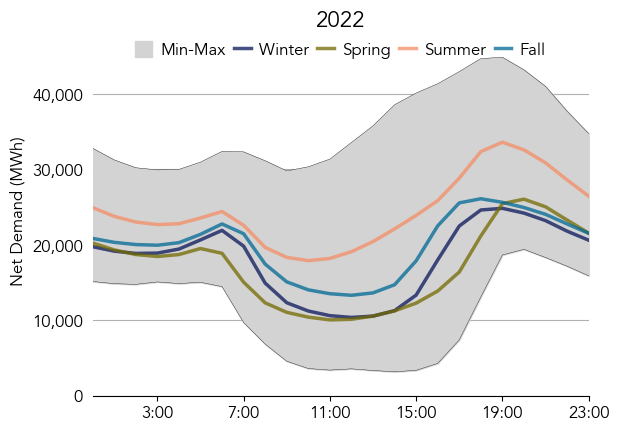

In [27]:
def _plot_uncertanty(ax, all_, year, legend):

    X_ = []
    for month in np.sort(all_.loc[all_['year'] == year, 'month'].unique()):
        for day in np.sort(all_.loc[all_['year'] == year, 'day'].unique()):
            x_ = np.zeros((24, 3))
            idx_   = (all_['year'] == year) & (all_['month'] == month) & (all_['day'] == day)
            all_p_ = all_.loc[idx_].reset_index(drop = True).copy()
            if all_p_.shape[0] != 72:
                pass
            else:
                j = 0
                for resource in ['solar', 'wind', 'demand']:
                    i_        = all_p_.loc[all_p_['resource'] == resource, 'interval'].to_numpy()
                    x_[i_, j] = all_p_.loc[all_p_['resource'] == resource, 'total'].to_numpy()

                    j += 1
                X_.append(x_)

    X_   = np.stack(X_)
    net_ = X_[..., 2] - X_[..., 0] - X_[..., 1]

    y_ = []
    for day_min, day_max in [[0, 90], [90, 180], [180, 270], [270, 365]]:
        y_.append(np.mean(net_[day_min:day_max, :], axis = 0))

    x_ = np.linspace(0, 23, 24)

    ax.set_title(r'{}'.format(year), fontsize = 16, y = 0.975)

    ax.fill_between(x_, np.max(net_, axis = 0), np.min(net_, axis = 0), 
                    alpha = 1., zorder = 5, color = 'lightgray', label = 'Min-Max')
    
    ax.plot(x_, np.max(net_, axis = 0), zorder = 10, color = 'k', lw = .25)
    ax.plot(x_, np.min(net_, axis = 0), zorder = 10, color = 'k', lw = .25)

    ax.plot(x_, y_[0], label = 'Winter', zorder = 10, alpha = .75, color = colors_1_[3], lw = 2.5)
    ax.plot(x_, y_[1], label = 'Spring', zorder = 10, alpha = .75, color = colors_3_[1], lw = 2.5)
    ax.plot(x_, y_[2], label = 'Summer', zorder = 10, alpha = .75, color = colors_1_[2], lw = 2.5)
    ax.plot(x_, y_[3], label = 'Fall', zorder = 10, alpha = .75, color = colors_1_[1], lw = 2.5)

    ax.set_ylabel('Net Demand (MWh)', fontsize = 12)
    #ax.set_xlabel('Period', fontsize = 12)

    if legend:
        ax.legend(loc            = 'upper center', 
                  frameon        = False, 
                  columnspacing  = .5, 
                  handletextpad  = .5,
                  ncol           = 5,
                  prop           = {'size': 12})

    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

    ax.spines[['right', 'top', 'left']].set_visible(False)

    ax.yaxis.set_tick_params(labelsize = 12, 
                             left      = False)

    ax.xaxis.set_tick_params(labelsize = 12)

    ax.set_xticks(x_[::-4], [r'{}:00'.format(int(x)) for x in x_][::-4])
    ax.grid(axis = 'y')
    ax.set_ylim(-1, 49000)
    ax.set_xlim(0, 23)

fig, ax = plt.subplots(1, 1)

_plot_uncertanty(ax, all_, year = 2019, legend = True)

plt.savefig(path_to_images + 'range_2019.png', bbox_inches = 'tight',
                                               dpi         = 250)

plt.show()

fig, ax = plt.subplots(1, 1)

_plot_uncertanty(ax, all_, year = 2020, legend = True)

plt.savefig(path_to_images + 'range_2020.png', bbox_inches = 'tight',
                                               dpi         = 250)

plt.show()

fig, ax = plt.subplots(1, 1)

_plot_uncertanty(ax, all_, year = 2021, legend = True)

plt.savefig(path_to_images + 'range_2021.png', bbox_inches = 'tight',
                                               dpi         = 250)

plt.show()


fig, ax = plt.subplots(1, 1)

_plot_uncertanty(ax, all_, year = 2022, legend = True)

plt.savefig(path_to_images + 'range_2022.png', bbox_inches = 'tight',
                                                    dpi         = 250)

plt.show()

In [28]:
year = 2022

solar_ppp_ = solar_.drop(columns = ['total']).copy()
wind_ppp_  = wind_.drop(columns = ['total']).copy()
load_ppp_  = load_.drop(columns = ['total']).copy()

solar_ppp_ = solar_ppp_.loc[solar_ppp_['type'] == 'actual'].reset_index(drop = True)
wind_ppp_  = wind_ppp_.loc[wind_ppp_['type'] == 'actual'].reset_index(drop = True)
load_ppp_  = load_ppp_.loc[load_ppp_['type'] == 'actual'].reset_index(drop = True)
    
solar_ppp_ = solar_ppp_.loc[solar_ppp_['year'] == year].reset_index(drop = True)
wind_ppp_  = wind_ppp_.loc[wind_ppp_['year'] == year].reset_index(drop = True)
load_ppp_  = load_ppp_.loc[load_ppp_['year'] == year].reset_index(drop = True)

solar_ppp_ = solar_ppp_.drop(columns = ['year', 'date', 'type'])
wind_ppp_  = wind_ppp_.drop(columns = ['year', 'date', 'type'])
load_ppp_  = load_ppp_.drop(columns = ['year', 'date', 'type'])
print(load_ppp_)

      PGE-TAC  SCE-TAC  SDGE-TAC  month  day  interval
0      9600.0   9106.0    1865.0      3   30         0
1      9325.0   8801.0    1801.0      3   30         1
2      9179.0   8649.0    1755.0      3   30         2
3      9148.0   8656.0    1747.0      3   30         3
4      9441.0   8942.0    1805.0      3   30         4
...       ...      ...       ...    ...  ...       ...
8616  12902.0  12199.0    2769.0     12   21        19
8617  12560.0  12009.0    2698.0     12   21        20
8618  12046.0  11684.0    2591.0     12   21        21
8619  11319.0  11191.0    2426.0     12   21        22
8620  10941.0  10802.0    2243.0     12   21        23

[8621 rows x 6 columns]


(356, 24)


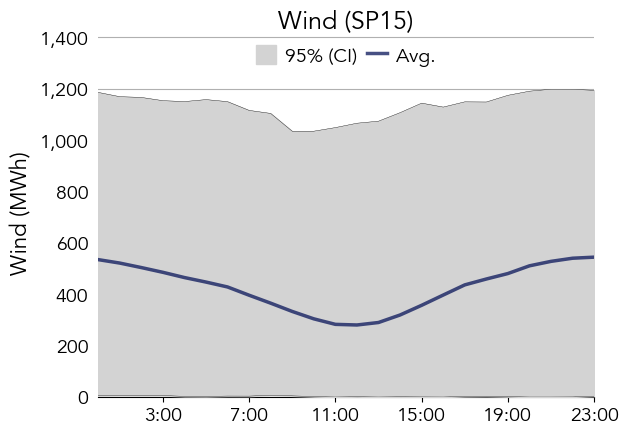

In [55]:
def _plot_zone_uncertanty(ax, df_, column, ylabel, title, legend):

    X_ = []
    for month in np.sort(df_['month'].unique()):
        for day in np.sort(df_['day'].unique()):
            x_    = np.zeros((24,))
            df_p_ = df_.loc[(df_['month'] == month) & (df_['day'] == day)].reset_index(drop = True).copy()
            if df_p_.shape[0] != 24:
                pass
            else:
                x_[df_p_['interval'].to_numpy()] = df_p_[column].to_numpy()
                X_.append(x_)
    X_ = np.stack(X_)
    print(X_.shape)
    
    u_ = np.quantile(X_, 0.975, axis = 0)
    l_ = np.quantile(X_, 0.025, axis = 0)
    l_[l_ < 0.] = 0.
    y_ = []
    for day_min, day_max in [[0, 90], [90, 180], [180, 270], [270, 365]]:
        y_.append(np.mean(X_[day_min:day_max, :], axis = 0))

    x_ = np.linspace(0, 23, 24)

    ax.set_title(title, fontsize = 18, y = 0.975)

    ax.fill_between(x_, l_, u_, 
                    alpha = 1., zorder = 5, color = 'lightgray', label = '95% (CI)')
    
    ax.plot(x_, l_, zorder = 10, color = 'k', lw = .25)
    ax.plot(x_, u_, zorder = 10, color = 'k', lw = .25)
    
    ax.plot(x_, np.mean(X_, axis = 0), label = 'Avg.', zorder = 10, alpha = .75, color = colors_1_[3], lw = 2.5)

    # ax.plot(x_, y_[0], label = 'Winter', zorder = 10, alpha = .75, color = colors_1_[3], lw = 2.5)
    # ax.plot(x_, y_[1], label = 'Spring', zorder = 10, alpha = .75, color = colors_3_[1], lw = 2.5)
    # ax.plot(x_, y_[2], label = 'Summer', zorder = 10, alpha = .75, color = colors_1_[2], lw = 2.5)
    # ax.plot(x_, y_[3], label = 'Fall', zorder = 10, alpha = .75, color = colors_1_[1], lw = 2.5)

    ax.set_ylabel(ylabel, fontsize = 16)
    #ax.set_xlabel('Period', fontsize = 12)

    if legend:
        ax.legend(loc            = 'upper center', 
                  frameon        = False, 
                  columnspacing  = .5, 
                  handletextpad  = .5,
                  ncol           = 5,
                  prop           = {'size': 14})

    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

    ax.spines[['right', 'top', 'left']].set_visible(False)

    ax.yaxis.set_tick_params(labelsize = 14, 
                             left      = False)

    ax.xaxis.set_tick_params(labelsize = 14)

    ax.set_xticks(x_[::-4], [r'{}:00'.format(int(x)) for x in x_][::-4])
    ax.grid(axis = 'y')
    ax.set_ylim(-1, u_.max()*1.2)
    ax.set_xlim(0, 23)

# fig, ax = plt.subplots(1, 1)

# _plot_zone_uncertanty(ax, load_ppp_, 
#                       column = 'PGE-TAC', 
#                       ylabel = 'Demand (MWh)',
#                       title  = 'PG&E',
#                       legend = True)


# plt.show()

fig, ax = plt.subplots(1, 1)

_plot_zone_uncertanty(ax, wind_ppp_, 
                      column = 'NP15', 
                      ylabel = 'Wind (MWh)',
                      title  = 'Wind (SP15)',
                      legend = True)


plt.show()

ValueError: need at least one array to stack

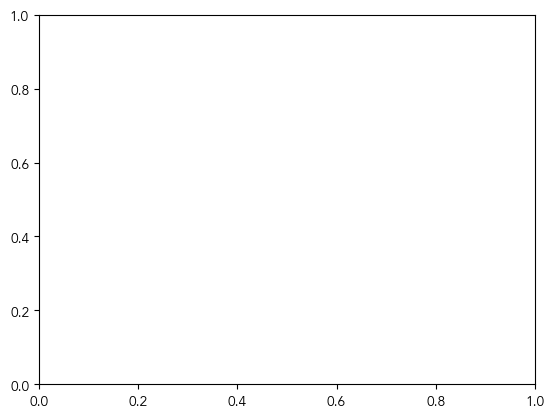

In [56]:
def _plot_load_variability_index(ax, all_, legend):
    years_ = np.sort(all_['year'].unique())[:-1]
    
    for year, i_year in zip(years_, range(len(years_))):
        X_ = []
        for month in np.sort(all_.loc[all_['year'] == year, 'month'].unique()):
            for day in np.sort(all_.loc[all_['year'] == year, 'day'].unique()):
                x_ = np.zeros((24, 3))
                idx_   = (all_['year'] == year) & (all_['month'] == month) & (all_['day'] == day)
                all_p_ = all_.loc[idx_].reset_index(drop = True).copy()
                if all_p_.shape[0] != 72:
                    pass
                else:
                    j = 0
                    for resource in ['solar', 'wind', 'demand']:
                        i_        = all_p_.loc[all_p_['resource'] == resource, 'interval'].to_numpy()
                        x_[i_, j] = all_p_.loc[all_p_['resource'] == resource, 'total'].to_numpy()

                        j += 1
                    X_.append(x_)

        X_   = np.stack(X_)
        net_ = X_[..., 2] - X_[..., 0] - X_[..., 1]

        x_ = np.linspace(0, 23, 24)
        y_ = np.std(net_, axis = 0)/np.mean(net_, axis = 0)

        ax.plot(x_, y_, label = year, zorder = 10, alpha = 1., color = colors_1_[i_year], lw = 3.75)

    ax.set_ylabel('Net Demand Variability Index', fontsize = 12)
    #ax.set_xlabel('Period', fontsize = 12)

    if legend:
        ax.legend(loc            = 'upper left', 
                  frameon        = False, 
                  columnspacing  = .5, 
                  handletextpad  = .5,
                  ncol           = 1,
                  prop           = {'size': 12})

    #ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

    ax.spines[['right', 'top', 'left']].set_visible(False)

    ax.yaxis.set_tick_params(labelsize = 12, 
                             left      = False)

    ax.xaxis.set_tick_params(labelsize = 12)

    ax.set_xticks(x_[::-4], [r'{}:00'.format(int(x)) for x in x_][::-4])
    ax.grid(axis = 'y')
    ax.set_ylim(-0., 0.45)
    ax.set_xlim(0, 23)


fig, ax = plt.subplots(1, 1)

_plot_load_variability_index(ax, all_, legend = True)

plt.savefig(path_to_images + 'LVI.png', bbox_inches = 'tight',
                                        dpi         = 250)

plt.show()

# Absolute day-ahead forecast errors for CAISO over the years 

Aggregated daily errors

In [57]:
solar_p_ = solar_.drop(columns = ['NP15', 'SP15', 'ZP26']).copy()
wind_p_  = wind_.drop(columns = ['NP15', 'SP15']).copy()
load_p_  = load_.drop(columns = ['PGE-TAC', 'SCE-TAC', 'SDGE-TAC']).copy()

solar_p_.loc[solar_p_['type'] == 'forecast', 'total'] = - solar_p_.loc[solar_p_['type'] == 'forecast', 'total']
wind_p_.loc[wind_p_['type'] == 'forecast', 'total']   = - wind_p_.loc[wind_p_['type'] == 'forecast', 'total']
load_p_.loc[load_p_['type'] == 'forecast', 'total']   = - load_p_.loc[load_p_['type'] == 'forecast', 'total']

solar_p_          = solar_p_.groupby(['year', 'month', 'day', 'interval']).agg('sum').reset_index(drop = False)
solar_p_['total'] = solar_p_['total'].abs()
solar_p_          = solar_p_[['year', 'total']]
solar_p_          = solar_p_.groupby(['year']).agg('mean').reset_index(drop = False).copy()

wind_p_          = wind_p_.groupby(['year', 'month', 'day', 'interval']).agg('sum').reset_index(drop = False)
wind_p_['total'] = wind_p_['total'].abs()
wind_p_          = wind_p_[['year', 'total']]
wind_p_          = wind_p_.groupby(['year']).agg('mean').reset_index(drop = False).copy()

load_p_          = load_p_.groupby(['year', 'month', 'day', 'interval']).agg('sum').reset_index(drop = False)
load_p_['total'] = load_p_['total'].abs()
load_p_          = load_p_[['year', 'total']]
load_p_          = load_p_.groupby(['year']).agg('mean').reset_index(drop = False).copy()

solar_p_['resource'] = 'solar'
wind_p_['resource']  = 'wind'
load_p_['resource']  = 'demand'

solar_pp_ = solar_.drop(columns = ['NP15', 'SP15', 'ZP26']).copy()
wind_pp_  = wind_.drop(columns = ['NP15', 'SP15']).copy()
load_pp_  = load_.drop(columns = ['PGE-TAC', 'SCE-TAC', 'SDGE-TAC']).copy()

solar_pp_['resource'] = 'solar'
wind_pp_['resource']  = 'wind'
load_pp_['resource']  = 'demand'

all_ = pd.concat([solar_pp_, wind_pp_, load_pp_], axis = 0).reset_index(drop = True)

bad_dates_ = []
for date in all_['date'].unique():
    idx_ = all_['date'] == date
    if idx_.sum() != (24*2*3):
        bad_dates_.append(date)
all_p_ = all_.loc[~all_['date'].isin(bad_dates_)].reset_index(drop = True)  

all_p_.loc[all_p_['resource'] == 'solar', 'total'] = - all_p_.loc[all_p_['resource'] == 'solar', 'total']
all_p_.loc[all_p_['resource'] == 'wind', 'total']  = - all_p_.loc[all_p_['resource'] == 'wind', 'total']

net_ = all_p_.drop(columns = ['date']).copy()
net_ = net_.groupby(['year', 'month', 'day', 'interval', 'type']).agg('sum').reset_index(drop = False)

net_.loc[net_['type'] == 'forecast', 'total'] = - net_.loc[net_['type'] == 'forecast', 'total']

error_             = net_.groupby(['year', 'month', 'day', 'interval']).agg('sum').reset_index(drop = False).copy()
error_['total']    = error_['total'].abs()
error_             = error_[['year', 'total']].copy()
error_             = error_.groupby(['year']).agg('mean').reset_index(drop = False).copy()
error_['resource'] = 'net'

all_p_ = pd.concat([load_p_, solar_p_, wind_p_, error_], axis = 0).reset_index(drop = True).copy()
all_p_ = all_p_.loc[all_p_['year'] != 2023].reset_index(drop = True)

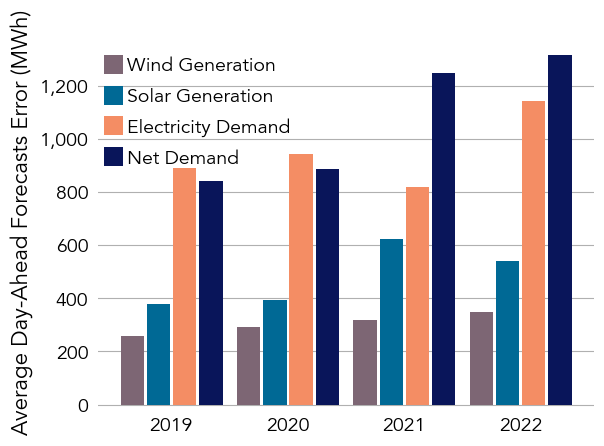

In [61]:
def _plot_average_error(ax, all_):
    width = 0.2

    N = all_['year'].unique().shape[0]

    x_ = np.linspace(0, N - 1, N)
    ax.bar(x_, all_.loc[all_['resource'] == 'wind', 'total'], width, label = 'Wind Generation', zorder = 10, color = colors_1_[0])

    x_ += 0.225
    ax.bar(x_, all_.loc[all_['resource'] == 'solar', 'total'], width, label = 'Solar Generation', zorder = 10, color = colors_1_[1])

    x_ += 0.225
    ax.bar(x_, all_.loc[all_['resource'] == 'demand', 'total'], width, label = 'Electricity Demand', zorder = 10, color = colors_1_[2])

    x_ += 0.225
    ax.bar(x_, all_.loc[all_['resource'] == 'net', 'total'], width, label = 'Net Demand', zorder = 10, color = colors_1_[3])

    ax.set_ylabel('Average Day-Ahead Forecasts Error (MWh)', fontsize = 16)

    ax.legend(loc            = 'center', 
              bbox_to_anchor = (.2, 0.8),
              frameon        = False, 
              columnspacing  = 0.4, 
              handletextpad  = .2,
              ncol           = 1,
              prop           = {'size': 14})

    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

    ax.yaxis.set_tick_params(labelsize = 14, 
                             left      = False)

    ax.xaxis.set_tick_params(labelsize = 14, 
                             left      = False)

    ax.set_xticks(np.array([0, 1, 2, 3]) + 0.335, [2019, 2020, 2021, 2022])
    ax.grid(axis = 'y')
    ax.set_ylim(-10,)

fig, ax = plt.subplots(1, 1)

_plot_average_error(ax, all_p_)
    
plt.savefig(path_to_images + 'forecast_errors_trend.png', bbox_inches = 'tight',
                                                          dpi         = 250)

plt.show()

# Transaction levels for real-time market/EIM 
Is CAISO buying more on EIM? 

In [33]:
wecc_ = pd.read_csv(path_to_data + 'wecc.csv', thousands=',')
wecc_['imports'] = wecc_['imports'].astype(float)
wecc_['exports'] = wecc_['exports'].astype(float)
wecc_['year']    = wecc_['year'].astype(int)

wecc_ = wecc_[['year', 'quarter', 'imports', 'exports', 'wheel-through']]
wecc_ = wecc_.loc[wecc_['year'] > 2017].reset_index(drop = True)
wecc_ = wecc_.loc[wecc_['year'] < 2024].reset_index(drop = True)

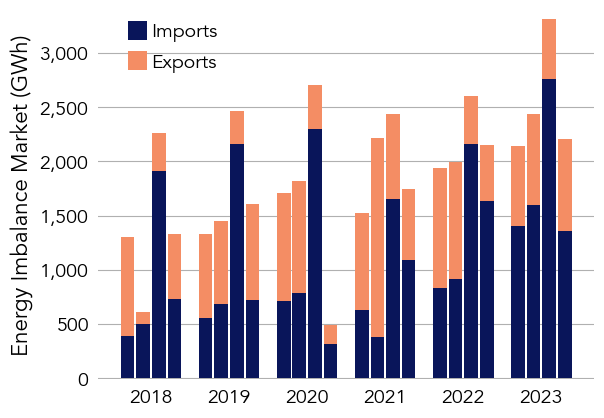

In [65]:
def _plot_wecc(ax, wecc_):


    units = 1000

    width = .35
    x_    = np.linspace(0, 1.2, 4) - 0.6

    x_p_ = []
    years_ = np.sort(wecc_['year'].unique())
    for year in years_:

        if year == 2019:
            ax.bar(x_, wecc_.loc[wecc_['year'] == year, 'imports']/units, width, 
                    color = colors_1_[3], label = 'Imports', zorder = 8)
            ax.bar(x_, wecc_.loc[wecc_['year'] == year, 'exports']/units, width, 
                    wecc_.loc[wecc_['year'] == year, 'imports']/units, 
                           color = colors_1_[2], label = 'Exports', zorder = 9)
            # ax.bar(x_, wecc_.loc[wecc_['year'] == year, 'wheel-through']/units, width/2., 
            #         color = colors_1_[0], label = 'Wheel-Through', zorder = 10)

        else:
            ax.bar(x_, wecc_.loc[wecc_['year'] == year, 'imports']/units, width, 
                    color = colors_1_[3], zorder = 8)
            ax.bar(x_, wecc_.loc[wecc_['year'] == year, 'exports']/units, width, 
                    wecc_.loc[wecc_['year'] == year, 'imports']/units, 
                           color = colors_1_[2], zorder = 9)
            # ax.bar(x_, wecc_.loc[wecc_['year'] == year, 'wheel-through']/units, width/2., 
            #                color = colors_1_[0], zorder = 10)
        x_p_.append(x_.mean())

        x_ += 2

    ax.set_ylabel('Energy Imbalance Market (GWh)', fontsize = 16)

    ax.legend(loc            = 'center', 
              bbox_to_anchor = (.15, 0.9),
              frameon        = False, 
              columnspacing  = 0.4, 
              handletextpad  = .2,
              ncol           = 1,
              prop           = {'size': 14})

    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

    ax.yaxis.set_tick_params(labelsize = 14, 
                             left      = False)

    ax.xaxis.set_tick_params(labelsize = 14, 
                             left      = False)

    ax.set_xticks(np.array(x_p_), years_)
    ax.grid(axis = 'y')
    ax.set_ylim(-10, 3400)
    
fig, ax = plt.subplots(1, 1)

_plot_wecc(ax, wecc_)

plt.savefig(path_to_images + 'CAISO_transaction.png', bbox_inches = 'tight',
                                                      dpi         = 250)


plt.show()

# Are ancillary services/operating reserves going up for CAISO? - Not going up. 
from scipy import statshttps://www.caiso.com/documents/2023-annual-report-on-market-issues-and-performance-jul-29-2024.pdf#page=18.47 Page 9

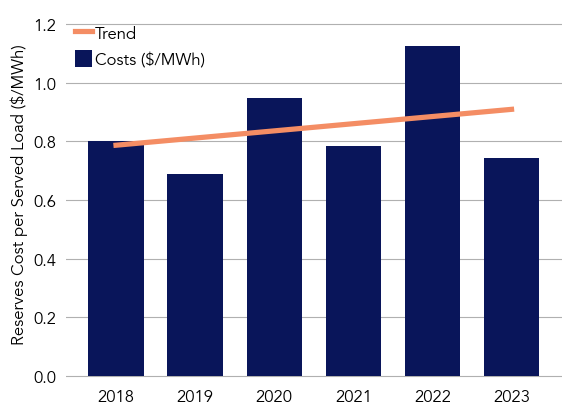

In [35]:
from scipy import stats

def _plot_reserves_cost(ax, costs_):
    
    _res = stats.linregress(costs_['year'], costs_[ 'USD/load_MWh'])
    ax.bar(costs_['year'], costs_[ 'USD/load_MWh'], 0.7, 
           label = 'Costs ($/MWh)', zorder = 9, color = colors_1_[3])

    ax.plot(costs_['year'], _res.intercept + _res.slope*costs_['year'], 
            zorder = 11, color = colors_1_[2], label = 'Trend', lw = 3.75)

    ax.legend(loc            = 'center', 
              bbox_to_anchor = (.15, 0.9),
              frameon        = False, 
              columnspacing  = 0.4, 
              handletextpad  = .2,
              ncol           = 1,
              prop           = {'size': 12})

    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

    ax.yaxis.set_tick_params(labelsize = 12, 
                             left      = False)

    ax.xaxis.set_tick_params(labelsize = 12, 
                             left      = False)

    ax.set_ylabel('Reserves Cost per Served Load ($/MWh)', fontsize = 12)
    ax.grid(axis = 'y')
    ax.set_ylim(-0.01,1.25)
    
costs_ = pd.read_csv(path_to_data + 'reserves_costs.csv')[['year', 'USD/load_MWh']]
costs_ = costs_.loc[costs_['year'] > 2017]

fig, ax = plt.subplots(1, 1)

_plot_reserves_cost(ax, costs_)

plt.savefig(path_to_images + 'reserves_costs.png', bbox_inches = 'tight',
                                                   dpi         = 250)

plt.show()


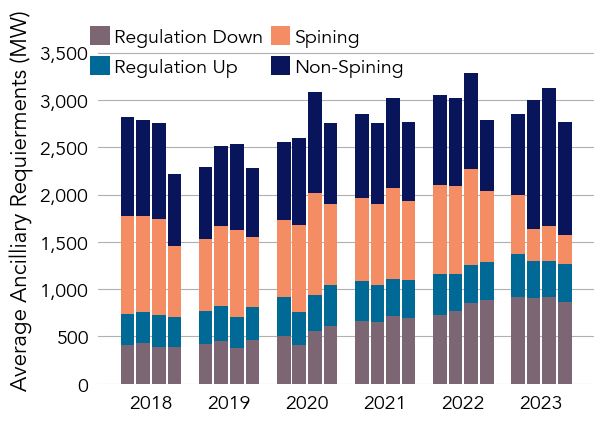

In [62]:
def _plot_ancilliary_services(ax, req_):


    units = 1000

    width = .35
    x_    = np.linspace(0, 1.2, 4) - 0.6

    x_p_ = []
    years_ = np.sort(req_['year'].unique())
    for year in years_:
        idx_ = req_['year'] == year

        if year == 2019:

            y_ = req_.loc[idx_ & (req_['type'] == 'reg_down'), ' power_mw'].to_numpy()
            ax.bar(x_, y_, width, color = colors_1_[0], zorder = 9, label = 'Regulation Down')

            z_ = req_.loc[idx_ & (req_['type'] == 'reg_up'), ' power_mw'].to_numpy()
            ax.bar(x_, z_, width, y_, color = colors_1_[1], zorder = 9, label = 'Regulation Up')

            w_ = req_.loc[idx_ & (req_['type'] == 'spin'), ' power_mw'].to_numpy()
            ax.bar(x_, w_, width, y_ + z_, color = colors_1_[2], zorder = 9, label = 'Spining')

            v_ = req_.loc[idx_ & (req_['type'] == 'non_spin'), ' power_mw'].to_numpy()
            ax.bar(x_, v_, width, y_ + z_ + w_, color = colors_1_[3], zorder = 9, label = 'Non-Spining')

        else:

            y_ = req_.loc[idx_ & (req_['type'] == 'reg_down'), ' power_mw'].to_numpy()
            ax.bar(x_, y_, width, color = colors_1_[0], zorder = 9)

            z_ = req_.loc[idx_ & (req_['type'] == 'reg_up'), ' power_mw'].to_numpy()
            ax.bar(x_, z_, width, y_, color = colors_1_[1], zorder = 9)

            w_ = req_.loc[idx_ & (req_['type'] == 'spin'), ' power_mw'].to_numpy()
            ax.bar(x_, w_, width, y_ + z_, color = colors_1_[2], zorder = 9)

            v_ = req_.loc[idx_ & (req_['type'] == 'non_spin'), ' power_mw'].to_numpy()
            ax.bar(x_, v_, width, y_ + z_ + w_, color = colors_1_[3], zorder = 9)
        
        x_p_.append(x_.mean())

        x_ += 2

    ax.set_ylabel('Average Ancilliary Requierments (MW)', fontsize = 16)

    ax.legend(loc            = 'center', 
              bbox_to_anchor = (.3, 0.9),
              frameon        = False, 
              columnspacing  = 0.4, 
              handletextpad  = .2,
              ncol           = 2,
              prop           = {'size': 14})

    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

    ax.yaxis.set_tick_params(labelsize = 14, 
                             left      = False)

    ax.xaxis.set_tick_params(labelsize = 14, 
                             left      = False)

    ax.set_xticks(np.array(x_p_), years_)
    ax.grid(axis = 'y')
    ax.set_ylim(-5, 3900)
    
    
req_ = pd.read_csv(path_to_data + 'ancilliary_requirements.csv')
req_ = req_.loc[req_['year'] > 2017]

fig, ax = plt.subplots(1, 1)

_plot_ancilliary_services(ax, req_)

plt.savefig(path_to_images + 'ancilliary_req.png', bbox_inches = 'tight',
                                                   dpi         = 250)


plt.show()

# CAISO Utilities and Traning Hubs map

In [9]:
_CAISO = gpd.read_file(path_to_data + r"maps/CAISO/California_Electric_Utility_Service_Territory.shp")
_US    = gpd.read_file(path_to_data + r"maps/US/tl_2022_us_state.shp")
world_ = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

/var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_68838/3690292292.py:81: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  PGE_  = _CAISO.iloc[[10]].buffer(0.03)
/var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_68838/3690292292.py:82: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  SDGE_ = _CAISO.iloc[[19]].buffer(0.03)
/var/folders/0c/ffx2kgyn7xq4krqrpsv67l3m0000gn/T/ipykernel_68838/3690292292.py:83: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  SCE_  = _CAISO.iloc[[23]].buffer(0.03)


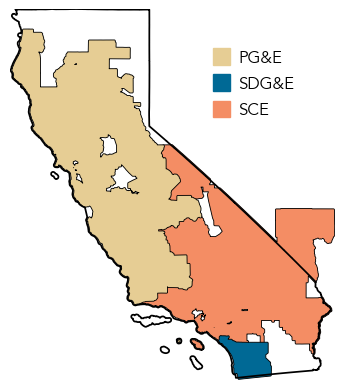

In [10]:
def _plot_untilities(ax, PGE_, SDGE_, SCE_):
    # ax.set_title(labels_[i], fontsize   = 20, 
    #                          fontweight = "bold")

    # _US.to_crs("EPSG:4326").plot(ax        = ax, 
    #                                       linewidth = 1.25, 
    #                                       edgecolor = 'k', 
    #                                       facecolor = 'k',
    #                                       alpha = 1.,
    #                                       color     = 'whitesmoke', 
    #                                       zorder    = 2)

    PGE_.to_crs("EPSG:4326").plot(ax        = ax, 
                                    linewidth = .625, 
                                    edgecolor = 'k', 
                                    facecolor = 'k', 
                                    color     = colors_1_[4], 
                                    label     = 'PG&E',
                                    alpha     = 1., 
                                    zorder    = 3)

    SDGE_.to_crs("EPSG:4326").plot(ax        = ax, 
                                    linewidth = .625, 
                                    edgecolor = 'k', 
                                    facecolor = 'k', 
                                    color     = colors_1_[1], 
                                    label     = 'SDG&E',
                                    alpha     = 1., 
                                    zorder    = 3)

    SCE_.to_crs("EPSG:4326").plot(ax        = ax, 
                                    linewidth = .625, 
                                    edgecolor = 'k', 
                                    facecolor = 'k', 
                                    color     = colors_1_[2], 
                                    label     = 'SCE',
                                    alpha     = 1., 
                                    zorder    = 2)

    _US.iloc[[13]].to_crs("EPSG:4326").plot(ax        = ax, 
                                          linewidth = 1.25, 
                                          edgecolor = 'k', 
                                          facecolor = 'k',
                                          alpha = 1.,
                                          color     = 'None', 
                                          zorder    = 4)

    # world_[world_['name'] == 'Mexico'].to_crs("EPSG:4326").plot(ax        = ax, 
    #                                                             linewidth = 2.5, 
    #                                                             edgecolor = 'k', 
    #                                                             facecolor = 'k',
    #                                                             color     = 'gainsboro', 
    #                                                             alpha     = 1., 
    #                                                             zorder    = 1)

    ax.legend(handles        = [mpatches.Patch(color = colors_1_[4], label = 'PG&E'),
                                mpatches.Patch(color = colors_1_[1], label = 'SDG&E'),
                                mpatches.Patch(color = colors_1_[2], label = 'SCE')], 
              loc            = 'center', 
              bbox_to_anchor = (.75, 0.8),
              frameon        = False, 
              columnspacing  = .5, 
              handletextpad  = .5,
              ncol           = 1,
              prop           = {'size': 12})

    x_ = [-126, -124, -122, -120, -118, -116, -114, -112]
    y_ = [32, 34, 36, 38, 40, 42, 44]

    # ax.set_xlabel('Longitude', fontsize = 14)
    # ax.set_ylabel('Latitude', fontsize = 14)

    ax.set_xlim(-124.5, -114)
    ax.set_ylim(32.5, 42)

    ax.set_xticks([], [])
    ax.set_yticks([], [])
    plt.axis('off')


PGE_  = _CAISO.iloc[[10]].buffer(0.03)
SDGE_ = _CAISO.iloc[[19]].buffer(0.03)
SCE_  = _CAISO.iloc[[23]].buffer(0.03)

fig, ax = plt.subplots(1, 1)

_plot_untilities(ax, PGE_, SDGE_, SCE_)

plt.savefig(path_to_images + 'utilities_map.png', bbox_inches = 'tight',
                                                  dpi         = 250)

plt.show()

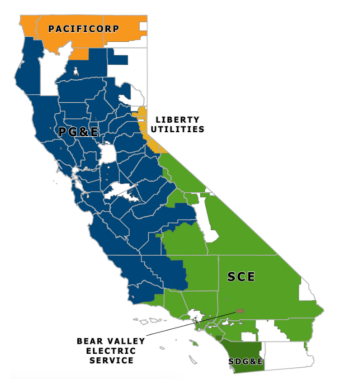

(759, 671, 4)


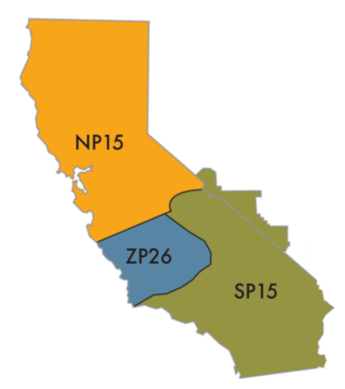

In [11]:
import matplotlib.image as mpimg

path_to_images = r"/Users/Guille/Desktop/caiso_power/images/"


utilities_ = mpimg.imread(path_to_images + r'utilities.png')
utilities_ = utilities_[:, 5:, :]

plt.figure()
plt.imshow(utilities_)
plt.axis('off')
plt.show()

hubs_ = mpimg.imread(path_to_images + r'hubs.png')
print(hubs_.shape)

hubs_[-50:, :, :]     = 1
hubs_[:50, :, :]      = 1
hubs_[:, :60, :]      = 1
hubs_[:, -40:, :]     = 1
hubs_[:300, -100:, :] = 1
hubs_                 = hubs_[50:-50, 50:-40, :]

plt.figure()
plt.imshow(hubs_)
plt.axis('off')
plt.show()

ValueError: need at least one array to stack

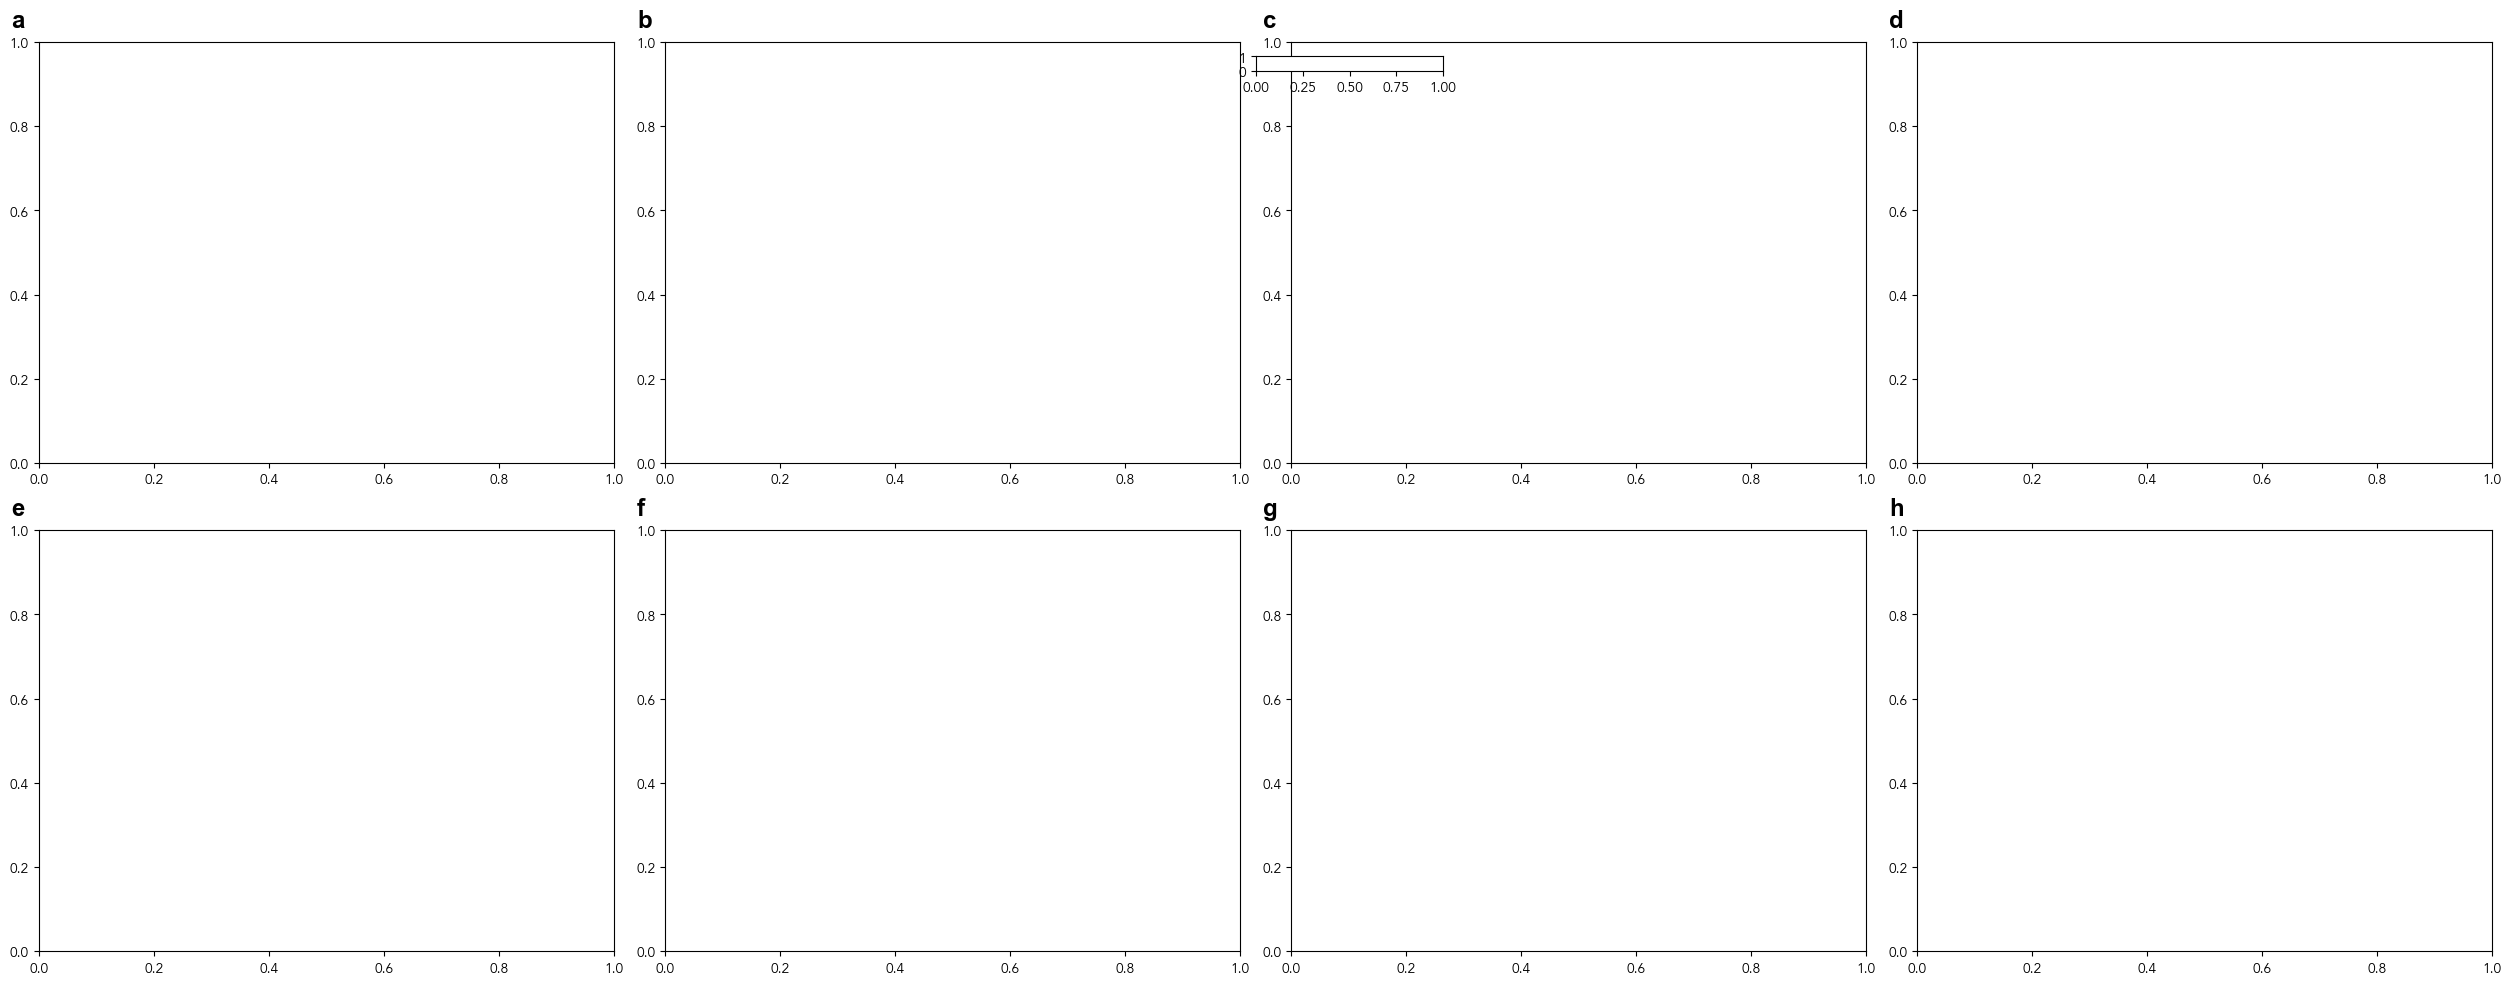

In [37]:
from matplotlib.transforms import ScaledTranslation

fig, _ax = plt.subplot_mosaic([['a', 'b', 'c', 'd'], 
                               ['e', 'f', 'g', 'h']], layout      = 'constrained', 
                                                      figsize     = (25, 9.75), 
                                                      gridspec_kw = {'width_ratios': [1, 1, 1, 1]})

cax = fig.add_axes([0.5, 0.9325, 0.075, 0.015])

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
                             fontsize  = 'xx-large', 
                             weight    = "bold",
                             va        = 'bottom', 
                             family    = 'Arial')




_plot_uncertanty(_ax['a'], all_, year = 2022, legend = True)

_plot_load_variability_index(_ax['b'], all_, legend = True)

_plot_average_error(_ax['e'], all_p_)

_plot_ancilliary_services(_ax['h'], req_)

_plot_reserves_cost(_ax['g'], costs_)

_plot_wecc(_ax['f'], wecc_)

_plot_untilities(_ax['c'], PGE_, SDGE_, SCE_)
_ax['c'].axis('off')

_ax['d'].imshow(hubs_)
_ax['d'].axis('off')

plt.savefig(path_to_images + 'intro.png', 
            bbox_inches = 'tight', 
            dpi         = 600)


plt.show()

In [59]:
def _plot_zone_uncertanty(ax, df_, column, ylabel, title, legend):

    X_ = []
    for month in np.sort(df_['month'].unique()):
        for day in np.sort(df_['day'].unique()):
            x_    = np.zeros((24,))
            df_p_ = df_.loc[(df_['month'] == month) & (df_['day'] == day)].reset_index(drop = True).copy()
            if df_p_.shape[0] != 24:
                pass
            else:
                x_[df_p_['interval'].to_numpy()] = df_p_[column].to_numpy()
                X_.append(x_)
    X_ = np.stack(X_)
    
    u_ = np.quantile(X_, .975, axis = 0)
    l_ = np.quantile(X_, .025, axis = 0)
    l_[l_ < 0.] = 0.
    y_ = []
    for day_min, day_max in [[0, 90], [90, 180], [180, 270], [270, 365]]:
        y_.append(np.mean(X_[day_min:day_max, :], axis = 0))

    x_ = np.linspace(0, 23, 24)

    ax.set_title(title, fontsize = 18, y = 0.975)

    ax.fill_between(x_, l_, u_, 
                    alpha = 1., zorder = 5, color = 'lightgray', label = '95% (CI)')
    
    ax.plot(x_, l_, zorder = 10, color = 'k', lw = .25)
    ax.plot(x_, u_, zorder = 10, color = 'k', lw = .25)

    ax.plot(x_, np.mean(X_, axis = 0), label = 'Mean', zorder = 10, alpha = .75, color = colors_1_[1], lw = 2.5)

    # ax.plot(x_, y_[0], label = 'Winter', zorder = 10, alpha = .75, color = colors_1_[3], lw = 2.5)
    # ax.plot(x_, y_[1], label = 'Spring', zorder = 10, alpha = .75, color = colors_3_[1], lw = 2.5)
    # ax.plot(x_, y_[2], label = 'Summer', zorder = 10, alpha = .75, color = colors_1_[2], lw = 2.5)
    # ax.plot(x_, y_[3], label = 'Fall', zorder = 10, alpha = .75, color = colors_1_[1], lw = 2.5)

    ax.set_ylabel(ylabel, fontsize = 16)
    #ax.set_xlabel('Period', fontsize = 12)

    if legend:
        ax.legend(loc            = 'upper center', 
                  frameon        = False, 
                  columnspacing  = .5, 
                  handletextpad  = .5,
                  ncol           = 5,
                  prop           = {'size': 14})

    ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

    ax.spines[['right', 'top', 'left']].set_visible(False)

    ax.yaxis.set_tick_params(labelsize = 14, 
                             left      = False)

    ax.xaxis.set_tick_params(labelsize = 14)

    ax.set_xticks(x_[::-4], [r'{}:00'.format(int(x)) for x in x_][::-4])
    ax.grid(axis = 'y')
    ax.set_ylim(-1, u_.max()*1.2)
    ax.set_xlim(0, 23)

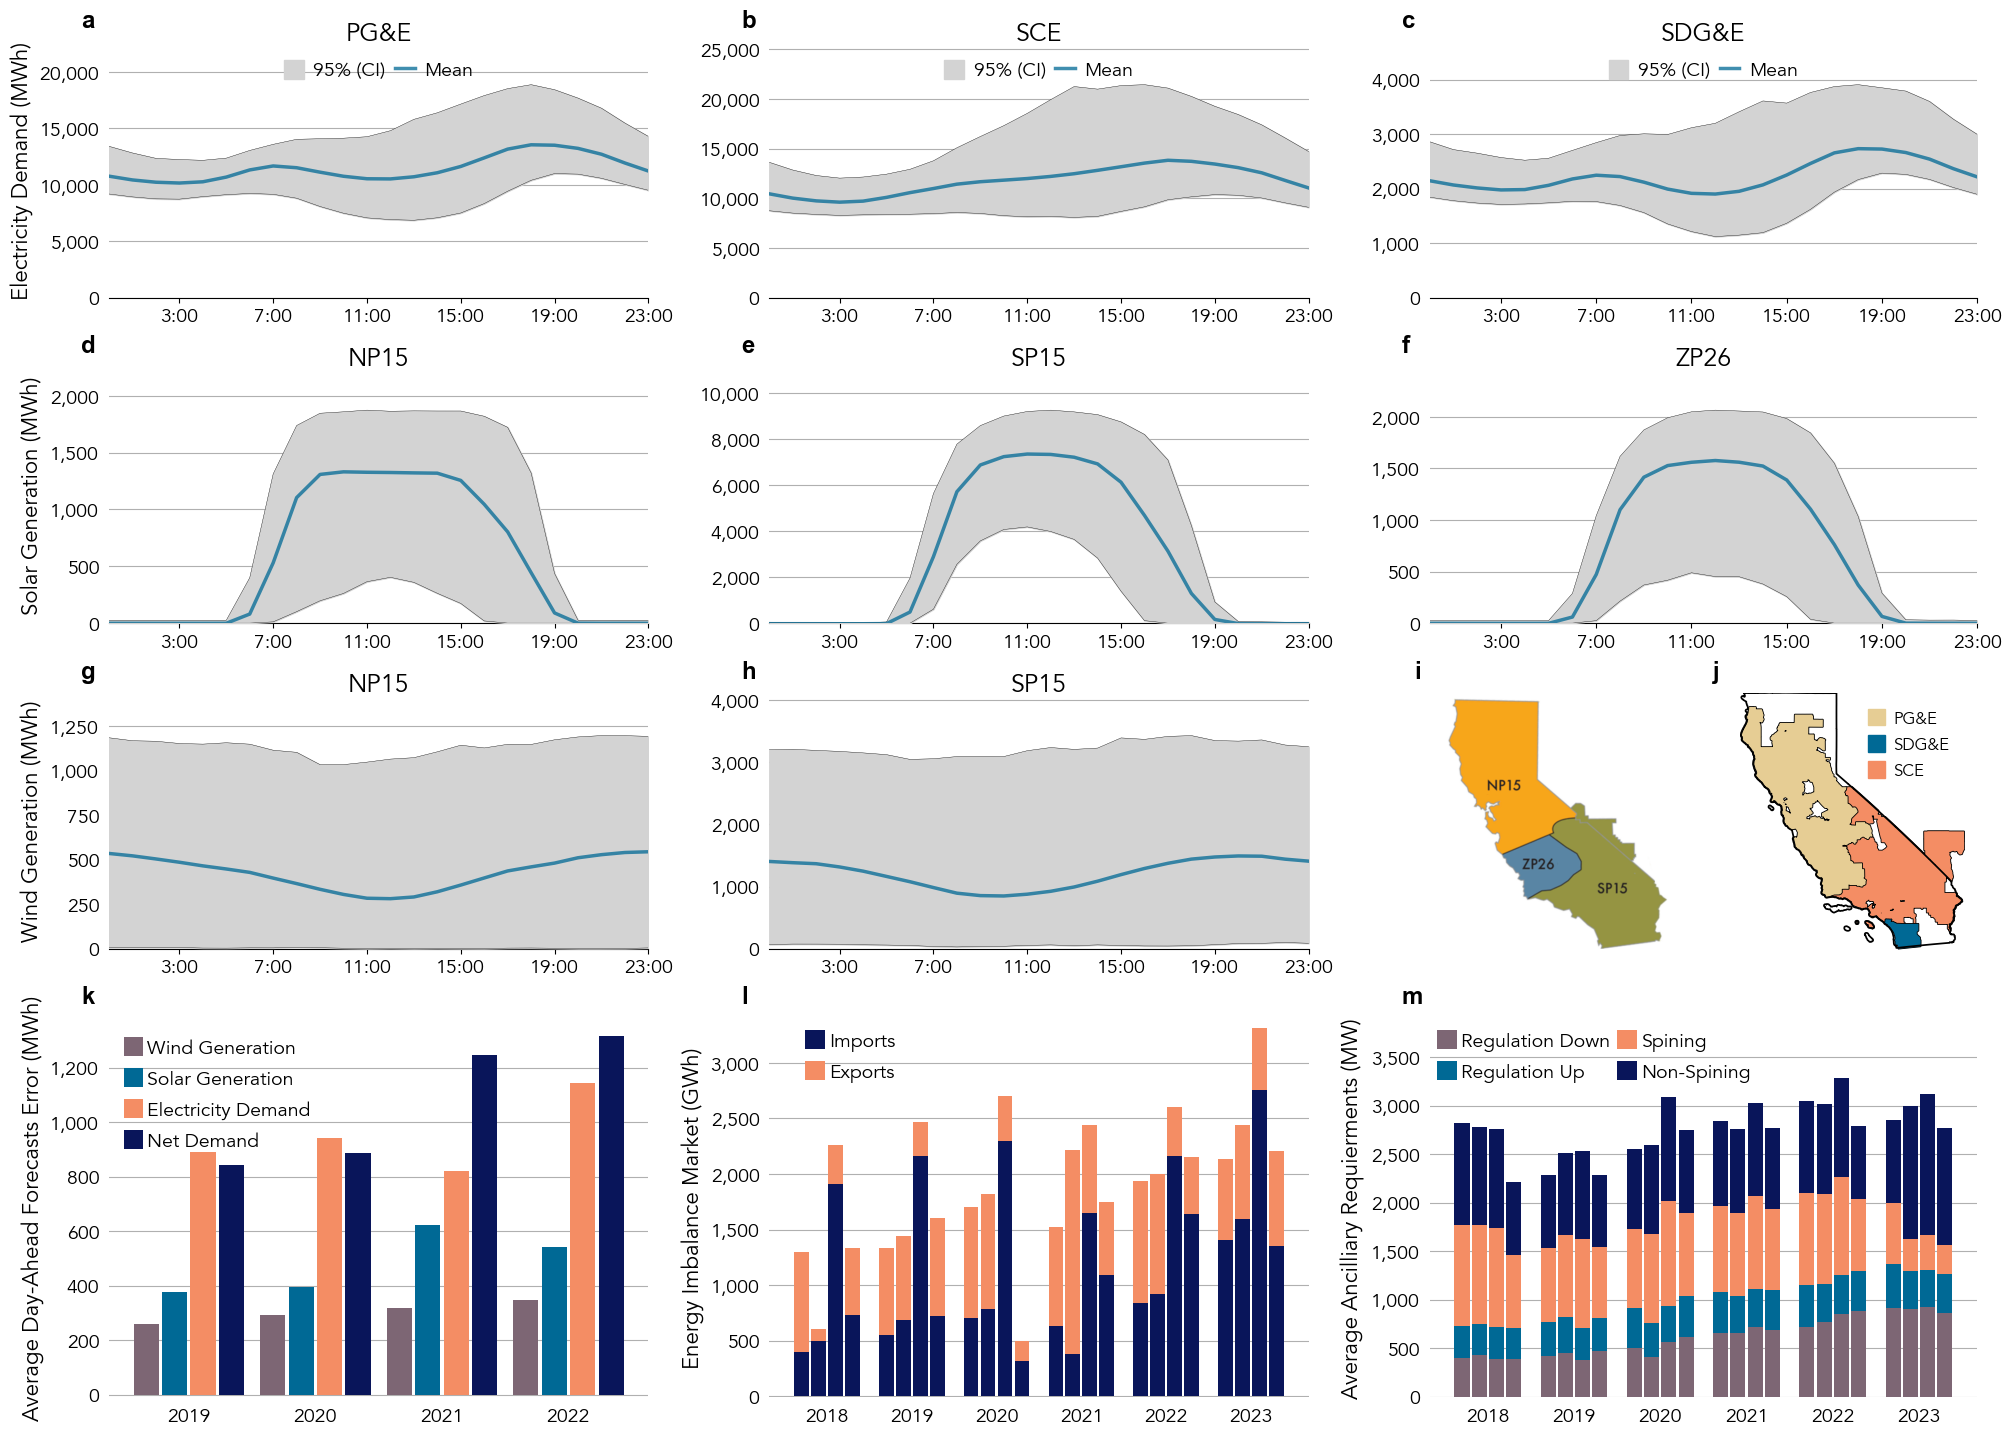

In [77]:
from matplotlib.transforms import ScaledTranslation

fig, _ax = plt.subplot_mosaic([['a', 'a', 'b', 'b', 'c', 'c'], 
                               ['d', 'd', 'e', 'e', 'f', 'f'],
                               ['g', 'g', 'h', 'h', 'i', 'j'], 
                               ['k', 'k', 'l', 'l', 'm', 'm']], 
                              layout      = 'constrained', 
                              figsize     = (20, 14.25),
                              gridspec_kw = {'width_ratios': [1, 1, 1, 1, 1, 1], 'height_ratios': [0.675, 0.675, 0.675, 1]})

cax = fig.add_axes([0.5, 0.9325, 0.075, 0.015])

for label, ax in _ax.items():
    ax.text(0.0, 1.0, label, transform = (ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
                             fontsize  = 'xx-large', 
                             weight    = "bold",
                             va        = 'bottom', 
                             family    = 'Arial')

_plot_zone_uncertanty(_ax['a'], load_ppp_, 
                      column = 'PGE-TAC', 
                      ylabel = 'Electricity Demand (MWh)',
                      title  = 'PG&E',
                      legend = True)

_plot_zone_uncertanty(_ax['b'], load_ppp_, 
                      column = 'SCE-TAC', 
                      ylabel = '',
                      title  = 'SCE', 
                      legend = True)

_plot_zone_uncertanty(_ax['c'], load_ppp_, 
                      column = 'SDGE-TAC', 
                      ylabel = '',
                      title  = 'SDG&E', 
                      legend = True)

_plot_zone_uncertanty(_ax['d'], solar_ppp_, 
                      column = 'NP15', 
                      ylabel = 'Solar Generation (MWh)',
                      title  = 'NP15',
                      legend = False)

_plot_zone_uncertanty(_ax['e'], solar_ppp_, 
                      column = 'SP15', 
                      ylabel = '',
                      title  = 'SP15', 
                      legend = False)

_plot_zone_uncertanty(_ax['f'], solar_ppp_, 
                      column = 'ZP26', 
                      ylabel = '',
                      title  = 'ZP26', 
                      legend = False)
     
_plot_zone_uncertanty(_ax['g'], wind_ppp_, 
                      column = 'NP15', 
                      ylabel = 'Wind Generation (MWh)',
                      title  = 'NP15',
                      legend = False)

_plot_zone_uncertanty(_ax['h'], wind_ppp_, 
                      column = 'SP15', 
                      ylabel = '',
                      title  = 'SP15', 
                      legend = False)


_ax['i'].imshow(hubs_)
_ax['i'].axis('off')


_plot_untilities(_ax['j'], PGE_, SDGE_, SCE_)
_ax['j'].axis('off')


_plot_average_error(_ax['k'], all_p_)


# _plot_reserves_cost(_ax['g'], costs_)

_plot_wecc(_ax['l'], wecc_)

_plot_ancilliary_services(_ax['m'], req_)


plt.savefig(path_to_images + 'intro_v4.pdf', 
            bbox_inches = 'tight', 
            dpi         = 600)

plt.show()